# MIMIC-III Clinical Database - Análisis Pre-ML

## Descripción del Dataset
MIMIC-III (Medical Information Mart for Intensive Care III) es una base de datos clínica que contiene información desidentificada de pacientes admitidos en unidades de cuidados intensivos (UCI) del Beth Israel Deaconess Medical Center.

**Tablas principales:**
- `PATIENTS`: Datos demográficos (género, fecha nacimiento, fecha muerte)
- `ADMISSIONS`: Ingresos hospitalarios con tipo de admisión, diagnóstico, mortalidad
- `ICUSTAYS`: Estadías en UCI con tiempos de entrada/salida

## Objetivo de Machine Learning
**Clasificación Binaria**: Predecir si un paciente morirá durante su hospitalización (`hospital_expire_flag`)

**Target**: `hospital_expire_flag` (0 = sobrevivió, 1 = falleció)

**Features potenciales**:
- Demográficas: género, edad
- Clínicas: tipo de admisión, ubicación de admisión, etnia, seguro
- UCI: duración de estadía en UCI (LOS), unidad de cuidado

## PASO 1: Cargar Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cargar tablas principales
patients = pd.read_csv('PATIENTS.csv')
admissions = pd.read_csv('ADMISSIONS.csv')
icustays = pd.read_csv('ICUSTAYS.csv')


## PASO 2: Crear Dataset Unificado mediante JOIN

Uniremos las 3 tablas usando `subject_id` y `hadm_id` como claves:

In [2]:
# Merge ADMISSIONS con PATIENTS
df = admissions.merge(patients[['subject_id', 'gender', 'dob']], on='subject_id', how='left')

# Merge con ICUSTAYS (agregando tiempo de estadía en UCI)
icu_summary = icustays.groupby('hadm_id').agg({
    'los': 'sum',  # Longitud total de estadía en UCI
    'first_careunit': 'first'  # Primera unidad de cuidado
}).reset_index()

df = df.merge(icu_summary, on='hadm_id', how='left')

# Calcular edad al momento de admisión
df['admittime'] = pd.to_datetime(df['admittime'])
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['admittime'] - df['dob']).dt.days / 365.25

# Seleccionar columnas relevantes
columns_to_keep = [
    'hospital_expire_flag',  # TARGET
    'age',
    'gender',
    'admission_type',
    'admission_location',
    'insurance',
    'ethnicity',
    'marital_status',
    'los',  # Length of stay en UCI
    'first_careunit'
]

df = df[columns_to_keep].copy()

print(f"Dataset unificado creado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset unificado creado: 129 filas, 10 columnas


## PASO 3: Ver Estructura del Dataset

In [3]:
df.head()

,hospital_expire_flag,age,gender,admission_type,admission_location,insurance,ethnicity,marital_status,los,first_careunit
0,0,70.633812,F,EMERGENCY,EMERGENCY ROOM ADMIT,Medicare,BLACK/AFRICAN AMERICAN,SEPARATED,1.6325,MICU
1,1,36.188912,F,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,Private,UNKNOWN/NOT SPECIFIED,SINGLE,13.8507,MICU
2,1,87.082820,F,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,Medicare,UNKNOWN/NOT SPECIFIED,NaN,2.6499,MICU
3,0,73.675565,F,EMERGENCY,EMERGENCY ROOM ADMIT,Medicare,WHITE,DIVORCED,2.1436,CCU
4,1,48.898015,M,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,Medicare,WHITE,DIVORCED,1.2938,MICU


In [4]:
df.shape

(129, 10)

In [5]:
df.dtypes.to_frame(name='dtype')

,dtype
hospital_expire_flag,int64
age,float64
gender,str
admission_type,str
admission_location,str
insurance,str
ethnicity,str
marital_status,str
los,float64
first_careunit,str


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hospital_expire_flag  129 non-null    int64  
 1   age                   129 non-null    float64
 2   gender                129 non-null    str    
 3   admission_type        129 non-null    str    
 4   admission_location    129 non-null    str    
 5   insurance             129 non-null    str    
 6   ethnicity             129 non-null    str    
 7   marital_status        113 non-null    str    
 8   los                   129 non-null    float64
 9   first_careunit        129 non-null    str    
dtypes: float64(2), int64(1), str(7)
memory usage: 10.2 KB


## PASO 4: Valores Faltantes

In [7]:
# Contar valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ No hay valores faltantes")

,Missing_Count,Missing_Percentage
marital_status,16,12.403101


## PASO 5: Gráfico del Target

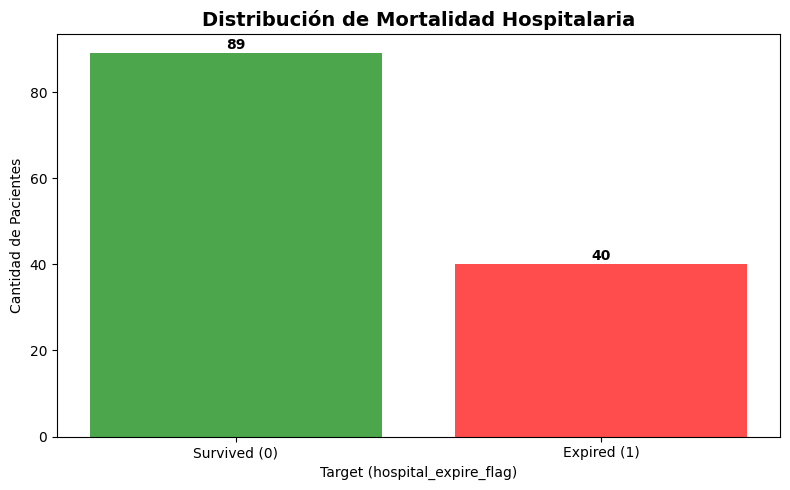


Balance del dataset:
Sobrevivieron: 89 (69.0%)
Fallecieron: 40 (31.0%)


In [8]:
# Distribución del target
target_counts = df['hospital_expire_flag'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['Survived (0)', 'Expired (1)'], target_counts.values, color=['green', 'red'], alpha=0.7)
plt.title('Distribución de Mortalidad Hospitalaria', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Pacientes')
plt.xlabel('Target (hospital_expire_flag)')

# Agregar valores sobre las barras
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nBalance del dataset:")
print(f"Sobrevivieron: {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Fallecieron: {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

---
# LIMPIEZA DE DATOS

## Tratamiento de Valores Faltantes

In [9]:
# LOS (length of stay) faltante = paciente no estuvo en UCI
df['los'] = df['los'].fillna(0)

# first_careunit faltante = paciente no estuvo en UCI
df['first_careunit'] = df['first_careunit'].fillna('NO_ICU')

# Verificar si quedan valores faltantes
remaining_nulls = df.isnull().sum().sum()
print(f"Valores faltantes después de limpieza: {remaining_nulls}")

if remaining_nulls > 0:
    print("\nColumnas con valores faltantes:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

Valores faltantes después de limpieza: 16

Columnas con valores faltantes:
marital_status    16
dtype: int64


## Tratamiento de Outliers

Analizamos variables numéricas para detectar valores extremos:

In [10]:
# Estadísticas de variables numéricas
print("=== ESTADÍSTICAS NUMÉRICAS ===")
print(df[['age', 'los']].describe())

# Detectar edades anómalas (MIMIC-III tiene fechas ficticias)
# En MIMIC-III, pacientes > 89 años tienen edad truncada a 300
print(f"\nPacientes con edad > 89 (codificados como ~300): {(df['age'] > 200).sum()}")

# Corregir edades truncadas
df.loc[df['age'] > 200, 'age'] = 90  # Asignamos edad representativa

print(f"\n✅ Outliers tratados")

=== ESTADÍSTICAS NUMÉRICAS ===
              age         los
count  129.000000  129.000000
mean    84.958651    4.694063
std     61.109048    6.485314
min     17.190965    0.105900
25%     63.715264    1.293800
50%     72.728268    2.255900
75%     82.989733    4.617900
max    300.035592   35.406500

Pacientes con edad > 89 (codificados como ~300): 9

✅ Outliers tratados


---
# PREPROCESAMIENTO

## Encoding de Variables Categóricas

In [11]:
# Identificar variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Variables categóricas: {categorical_cols}")

# One-Hot Encoding manual (sin sklearn)
df_encoded = df.copy()

for col in categorical_cols:
    # Crear dummies manualmente
    dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)
    df_encoded.drop(col, axis=1, inplace=True)

print(f"\n✅ Encoding completado")
print(f"Shape después de encoding: {df_encoded.shape}")

Variables categóricas: ['gender', 'admission_type', 'admission_location', 'insurance', 'ethnicity', 'marital_status', 'first_careunit']

✅ Encoding completado
Shape después de encoding: (129, 30)


## Separar Features y Target

In [12]:
# Target
y = df_encoded['hospital_expire_flag'].values

# Features (todas excepto el target)
X = df_encoded.drop('hospital_expire_flag', axis=1).values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nNombre de features (primeras 10):")
print(df_encoded.drop('hospital_expire_flag', axis=1).columns.tolist()[:10])

X shape: (129, 29)
y shape: (129,)

Nombre de features (primeras 10):
['age', 'los', 'gender_M', 'admission_type_EMERGENCY', 'admission_type_URGENT', 'admission_location_EMERGENCY ROOM ADMIT', 'admission_location_PHYS REFERRAL/NORMAL DELI', 'admission_location_TRANSFER FROM HOSP/EXTRAM', 'admission_location_TRANSFER FROM SKILLED NUR', 'insurance_Medicaid']


## Train-Test Split Manual (80-20)

In [13]:
# Configuración
np.random.seed(42)
test_size = 0.2

# Generar índices aleatorios
n_samples = len(X)
indices = np.random.permutation(n_samples)

# Calcular punto de corte
test_size_abs = int(n_samples * test_size)
train_size_abs = n_samples - test_size_abs

# Dividir índices
train_indices = indices[:train_size_abs]
test_indices = indices[train_size_abs:]

# Crear conjuntos
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print(f"✅ Split completado")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"\nDistribución target en Train: {np.bincount(y_train)}")
print(f"Distribución target en Test: {np.bincount(y_test)}")

✅ Split completado
Train: 104 muestras
Test: 25 muestras

Distribución target en Train: [73 31]
Distribución target en Test: [16  9]


## Escalado Manual (StandardScaler)

Fórmula: `x_scaled = (x - mean) / std`

**IMPORTANTE**: Calcular media y desviación estándar SOLO con datos de entrenamiento para evitar data leakage.

In [14]:
# Calcular media y desviación estándar del TRAIN set
X_train = X_train.astype(float)
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Evitar división por cero (columnas constantes)
std_train[std_train == 0] = 1

# Aplicar escalado
X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train  # Usar estadísticas del train

print("✅ Escalado completado")
print(f"\nMedia de X_train_scaled (primeras 5 features): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Desv. Std de X_train_scaled (primeras 5 features): {X_train_scaled.std(axis=0)[:5]}")

✅ Escalado completado

Media de X_train_scaled (primeras 5 features): [-4.85722573e-17 -2.65279252e-16 -2.77555756e-17 -9.50094704e-17
 -1.55858232e-16]
Desv. Std de X_train_scaled (primeras 5 features): [1. 1. 1. 1. 1.]


---
# VALIDACIÓN FINAL

## 1. Verificar Data Leakage

In [15]:
# Verificar que no hay índices compartidos entre train y test
shared_indices = np.intersect1d(train_indices, test_indices)

if len(shared_indices) == 0:
    print("✅ No hay data leakage (índices únicos en train y test)")
else:
    print(f"⚠️ ALERTA: {len(shared_indices)} índices compartidos detectados")

✅ No hay data leakage (índices únicos en train y test)


## 2. Verificar NaN e Infinitos

In [16]:
# Convert to float to ensure numpy can perform isnan/isinf checks
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

# Verificar NaN
nan_train = np.isnan(X_train_scaled).sum()
nan_test = np.isnan(X_test_scaled).sum()

# Verificar infinitos
inf_train = np.isinf(X_train_scaled).sum()
inf_test = np.isinf(X_test_scaled).sum()

print(f"NaN en X_train_scaled: {nan_train}")
print(f"NaN en X_test_scaled: {nan_test}")
print(f"Infinitos en X_train_scaled: {inf_train}")
print(f"Infinitos en X_test_scaled: {inf_test}")

if nan_train == 0 and nan_test == 0 and inf_train == 0 and inf_test == 0:
    print("\n✅ Datos limpios (sin NaN ni infinitos)")
else:
    print("\n⚠️ ALERTA: Hay NaN o infinitos en los datos")

NaN en X_train_scaled: 0
NaN en X_test_scaled: 0
Infinitos en X_train_scaled: 0
Infinitos en X_test_scaled: 0

✅ Datos limpios (sin NaN ni infinitos)


## 3. Comparar Distribuciones Train vs Test

In [17]:
# Comparar media y std de las primeras 5 features
print("=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===")
print("\nMEDIA:")
print(f"Train: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.mean(axis=0)[:5]}")

print("\nDESVIACIÓN ESTÁNDAR:")
print(f"Train: {X_train_scaled.std(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.std(axis=0)[:5]}")

print("\n✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)")

=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===

MEDIA:
Train: [-4.85722573e-17 -2.65279252e-16 -2.77555756e-17 -9.50094704e-17
 -1.55858232e-16]
Test:  [ 0.28407432  0.00451356 -0.15642942  0.32616404 -0.14002801]

DESVIACIÓN ESTÁNDAR:
Train: [1. 1. 1. 1. 1.]
Test:  [8.19965406e-01 1.08426566e+00 1.00591832e+00 1.66533454e-16
 8.32667268e-17]

✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)


## Resumen Final

In [18]:
print("="*60)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*60)
print(f"Dataset original: {df.shape}")
print(f"Features después de encoding: {X.shape[1]}")
print(f"Train set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"\nTarget (mortalidad hospitalaria):")
print(f"  - Clase 0 (sobrevivió): {(y==0).sum()} casos")
print(f"  - Clase 1 (falleció): {(y==1).sum()} casos")
print(f"\n✅ Datos listos para entrenamiento de modelos de clasificación")
print("="*60)

RESUMEN DEL PREPROCESAMIENTO
Dataset original: (129, 10)
Features después de encoding: 29
Train set: (104, 29)
Test set: (25, 29)

Target (mortalidad hospitalaria):
  - Clase 0 (sobrevivió): 89 casos
  - Clase 1 (falleció): 40 casos

✅ Datos listos para entrenamiento de modelos de clasificación
